# **Sistema de Inspección Visual Automatizada**

### **Información general**

**Asignatura:** Visión por computador  
**Actividad:** Semana 1 - Introducción a la visión por computador   
**Fecha:** 13 de julio de 2026    
**Dataset:** Imágenes de granos de café  
**Fuente:** Elaboración propia a partir de imágenes reales de Pexels y Unsplash   
**Autores:**  
- Aponte Zurita William Romario 
- Rodríguez Vélez Ximena Jhoana  
- Viteri Ayala Flavia Kamila  

### **Objetivo del proyecto**

Este notebook construye, paso a paso y con el pipeline clasico de vision por
computador visto en las dos sesiones de clase, un sistema de inspección visual
automatizada que:

1. Carga un dataset propio de imagenes reales (granos de cafe, fotos propias
   descargadas de Pexels y Unsplash).
2. Preprocesa, filtra y realza esas imagenes.
3. Segmenta los objetos presentes en una escena de inspeccion.
4. Cuenta los objetos detectados y extrae sus rasgos (area, forma).
5. Marca automaticamente cada objeto como **OK** (verde) o **DEFECTO** (rojo)
   usando deteccion de anomalias por z-score sobre el area.
6. (Bonus) Simula una banda transportadora y hace tracking simple de objetos
   entre fotogramas.

**Nota sobre el dataset:** el grupo intentó implementar el algoritmo
primero con fotos de hojas individuales que no traían varios objetos 
por imagen ni defectos reales visibles, esto nos obligaba a simular 
casi todo (defectos, anomalías, iluminación, etc.). 

Buscamos otras fotos reales en Pexels/Unsplash y esta vez si encontramos 
varias fotos que traen varios granos de cafe reales, ya separados, 
sobre fondo claro, justo lo que se necesita para contar objetos sin inventar 
nada. 

Lo unico que no encontramos en esas fotos fue un grano con dano fisico real, 
asi que para esa parte usamos un grano real y dañado que ya teniamos previamente
fotografiado (grano mordido/partido) y lo insertamos en una imagen con varios 
granos. Esta decision se documenta explicitamente en la Seccion 14, 
que es el unico punto del pipeline principal (Secciones 1-16) que no es 100% 
dato crudo sin modificar.

----
## **Sección 1:** Configuración del entorno y carga de librerías

In [1]:
import os
import glob
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data as skimage_data
from skimage import img_as_ubyte

# Configuración general de las figuras: un tamaño cómodo para ver detalles
# de los granos (textura, grietas) sin que las imágenes se vean diminutas.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"  # por defecto mostramos en escala de grises

SEMILLA_ALEATORIA = 42  # TODO: ajustar según su dataset (fija la reproducibilidad de ruido/orden aleatorio)
np.random.seed(SEMILLA_ALEATORIA)
random.seed(SEMILLA_ALEATORIA)

print("Librerías cargadas correctamente.")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

Librerías cargadas correctamente.
OpenCV version: 5.0.0
NumPy version: 2.4.2


## **Sección 2:** Carga del dataset

En esta sección se realiza la búsqueda y carga de todas las imágenes de la
utilizadas para el ejercicio, convirtiendo de BGR (orden de color nativo de 
OpenCV) a RGB (orden que espera Matplotlib).

In [ ]:
RUTA_DATASET = os.path.join("img", "granos_cafe2")
EXTENSIONES_VALIDAS = ("*.png", "*.jpg", "*.jpeg")


def cargar_rutas_imagenes(carpeta, extensiones=EXTENSIONES_VALIDAS):
    """Busca en 'carpeta' todos los archivos que calcen con las extensiones dadas."""
    rutas = []
    for patron in extensiones:
        rutas.extend(glob.glob(os.path.join(carpeta, patron)))
    return sorted(rutas)


def cargar_dataset(carpeta=RUTA_DATASET):
    """
    Intenta cargar el dataset real del grupo (fotos de granos de cafe
    descargadas de Pexels). Si la carpeta no existe o no contiene imagenes
    legibles (por ejemplo, al ejecutar este notebook en otra maquina sin el
    dataset local), se hace un fallback automatico a imagenes de muestra de
    skimage.data, para que el notebook siga siendo ejecutable de inicio a fin
    sin depender de rutas locales de un unico computador.
    """
    rutas = cargar_rutas_imagenes(carpeta)
    imagenes, nombres = [], []
    for ruta in rutas:
        imagen_bgr = cv2.imread(ruta)
        if imagen_bgr is None:
            continue  # archivo corrupto o no soportado: lo saltamos sin detener el notebook
        imagenes.append(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
        nombres.append(os.path.basename(ruta))

    if len(imagenes) > 0:
        return imagenes, nombres, "dataset real (granos_cafe2)"

    # --- Fallback: no se encontro el dataset real, usamos muestras de skimage ---
    print("Aviso: no se encontro el dataset real en:", carpeta)
    print("Se usaran imagenes de muestra de skimage.data como respaldo.")
    muestras_fallback = {
        "chelsea.png": skimage_data.chelsea(),
        "coffee.png": skimage_data.coffee(),
        "astronaut.png": skimage_data.astronaut(),
        "rocket.png": skimage_data.rocket(),
    }
    imagenes = [img_as_ubyte(img) for img in muestras_fallback.values()]
    nombres = list(muestras_fallback.keys())
    return imagenes, nombres, "fallback (skimage.data)"


imagenes_dataset, nombres_dataset, origen_dataset = cargar_dataset()


def obtener_imagen_por_nombre(nombre_archivo, valor_por_defecto_indice=0):
    """Busca una imagen especifica del dataset por su nombre de archivo
    (nos permite referirnos a fotos concretas, como una bandeja con varios
    granos o un grano con dano real, en lugar de depender del orden en que
    se cargaron). Si no se encuentra (por ejemplo, en el modo de respaldo con
    skimage), devolvemos una imagen por defecto para que el notebook no truene."""
    if nombre_archivo in nombres_dataset:
        return imagenes_dataset[nombres_dataset.index(nombre_archivo)]
    return imagenes_dataset[valor_por_defecto_indice]


print(f"Origen del dataset usado: {origen_dataset}")
print(f"Numero de imagenes cargadas: {len(imagenes_dataset)}")

Origen del dataset usado: dataset real (granos_cafe2)
Numero de imagenes cargadas: 17


## Seccion 3: Exploracion del dataset (dimensiones, tipos, galeria normal vs. defecto) — [SESION 1]

**Esta seccion es importante porque...** antes de aplicar cualquier filtro
hay que entender con que datos se esta trabajando: resolucion, tipo de dato,
numero de canales y si existe variabilidad relevante entre imagenes.

**Aqui se realiza...** una inspeccion basica (shape, dtype, min/max) de las
primeras imagenes, y se construye una galeria comparativa "normal vs
defecto" usando **fotos reales de ambos casos**: recortamos granos sanos de
una bandeja real (`14.png`) y los comparamos contra dos granos con dano real
fotografiado (`grano_cafe_defectuoso_01.png`, con un pedazo mordido/partido,
y `grano_cafe_defectuoso_20.png`, con manchas oscuras de moho).

**Sirve para...** decidir mas adelante que tan facil o dificil es distinguir
"a simple vista" (histograma, bordes) un grano normal de uno con defecto, y
para tener material de comparacion real en el resto de la Sesion 1.

1.jpg: shape=(5905, 3937, 3), dtype=uint8, min=0, max=255
10.jpg: shape=(4000, 6000, 3), dtype=uint8, min=0, max=255
11.jpg: shape=(3264, 3264, 3), dtype=uint8, min=0, max=255
12.jpg: shape=(4000, 4000, 3), dtype=uint8, min=0, max=255
13.jpg: shape=(3456, 5184, 3), dtype=uint8, min=0, max=255


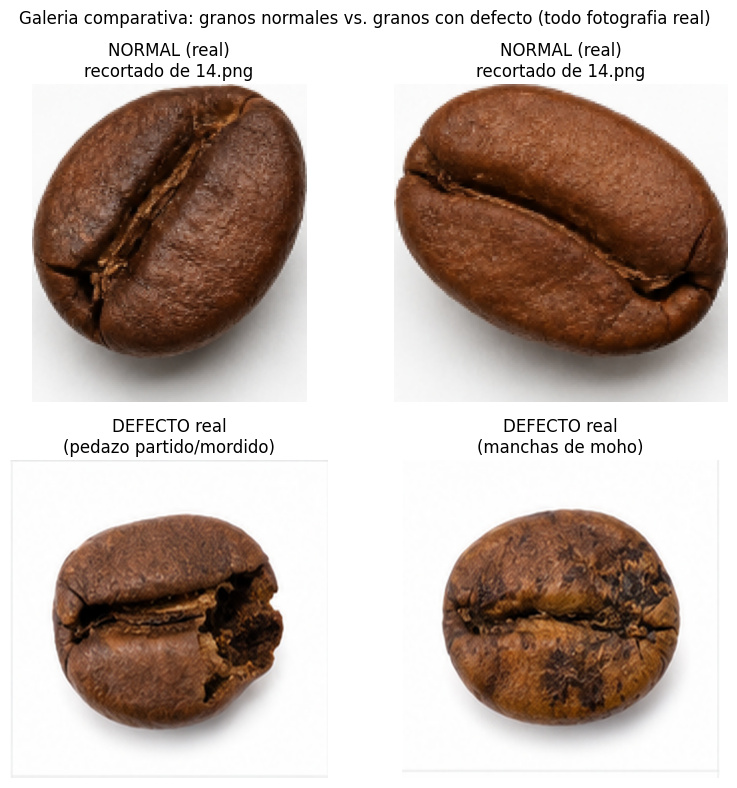

In [3]:
NOMBRE_BANDEJA_SANA = "14.png"  # TODO: ajustar según su dataset (bandeja real con granos sanos)
NOMBRE_GRANO_DEFECTO_FORMA = "grano_cafe_defectuoso_01.png"  # grano real con un pedazo partido/mordido
NOMBRE_GRANO_DEFECTO_COLOR = "grano_cafe_defectuoso_20.png"  # grano real con manchas de moho

# Mostramos dimensiones y tipos de dato de las primeras imagenes para saber
# con que estamos trabajando (fotos reales descargadas de Pexels, por lo que
# el tamanio varia bastante de una a otra).
for nombre, imagen in list(zip(nombres_dataset, imagenes_dataset))[:5]:
    print(f"{nombre}: shape={imagen.shape}, dtype={imagen.dtype}, min={imagen.min()}, max={imagen.max()}")


def segmentar_umbral_fijo_preliminar(imagen_gris, umbral=200):
    """Version preliminar del umbral fijo (se formaliza en la Seccion 10),
    la necesitamos aqui solo para poder recortar granos individuales de una
    bandeja real y armar la galeria comparativa."""
    _, mascara = cv2.threshold(imagen_gris, umbral, 255, cv2.THRESH_BINARY_INV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)


def recortar_granos_de_bandeja(bandeja_rgb, num_granos=2, lado_canvas=700):
    """Segmenta una bandeja real con varios granos y devuelve recortes
    individuales de los primeros 'num_granos' encontrados, para poder
    mostrarlos como ejemplos de granos 'normales' reales."""
    bandeja_rgb = cv2.resize(bandeja_rgb, (lado_canvas, lado_canvas))
    gris = cv2.cvtColor(bandeja_rgb, cv2.COLOR_RGB2GRAY)
    mascara = segmentar_umbral_fijo_preliminar(gris)
    num_etiquetas, etiquetas, estadisticas, _ = cv2.connectedComponentsWithStats(mascara, connectivity=8)
    recortes = []
    for etiqueta in range(1, num_etiquetas):
        if estadisticas[etiqueta, cv2.CC_STAT_AREA] < 200:
            continue
        x = estadisticas[etiqueta, cv2.CC_STAT_LEFT]
        y = estadisticas[etiqueta, cv2.CC_STAT_TOP]
        w = estadisticas[etiqueta, cv2.CC_STAT_WIDTH]
        h = estadisticas[etiqueta, cv2.CC_STAT_HEIGHT]
        recortes.append(bandeja_rgb[y:y + h, x:x + w])
        if len(recortes) >= num_granos:
            break
    return recortes


bandeja_sana_rgb = obtener_imagen_por_nombre(NOMBRE_BANDEJA_SANA)
granos_sanos_recortados = recortar_granos_de_bandeja(bandeja_sana_rgb, num_granos=2)
granos_defecto_reales = [
    obtener_imagen_por_nombre(NOMBRE_GRANO_DEFECTO_FORMA),
    obtener_imagen_por_nombre(NOMBRE_GRANO_DEFECTO_COLOR),
]

fig, ejes = plt.subplots(2, 2, figsize=(8, 8))
ejes[0, 0].imshow(granos_sanos_recortados[0])
ejes[0, 0].set_title("NORMAL (real)\nrecortado de 14.png")
ejes[0, 0].axis("off")
ejes[0, 1].imshow(granos_sanos_recortados[1])
ejes[0, 1].set_title("NORMAL (real)\nrecortado de 14.png")
ejes[0, 1].axis("off")
ejes[1, 0].imshow(granos_defecto_reales[0])
ejes[1, 0].set_title("DEFECTO real\n(pedazo partido/mordido)")
ejes[1, 0].axis("off")
ejes[1, 1].imshow(granos_defecto_reales[1])
ejes[1, 1].set_title("DEFECTO real\n(manchas de moho)")
ejes[1, 1].axis("off")
plt.suptitle("Galeria comparativa: granos normales vs. granos con defecto (todo fotografia real)")
plt.tight_layout()
plt.show()

## Seccion 4: Preprocesamiento estandarizado: conversion a escala de grises y tamano comun — [SESION 1]

**Esta seccion es importante porque...** comparar histogramas, bordes o areas
entre imagenes solo tiene sentido si todas estan en la misma escala y con la
misma resolucion; si no, una imagen mas grande "gana" artificialmente en
cualquier metrica basada en conteo de pixeles.

**Aqui se realiza...** la conversion de cada imagen a escala de grises con
`cv2.cvtColor` y su redimension a un tamano fijo con `cv2.resize`.

**Sirve para...** dejar un conjunto de imagenes homogeneo que sera la entrada
de todos los filtros y algoritmos de segmentacion de las secciones
siguientes.

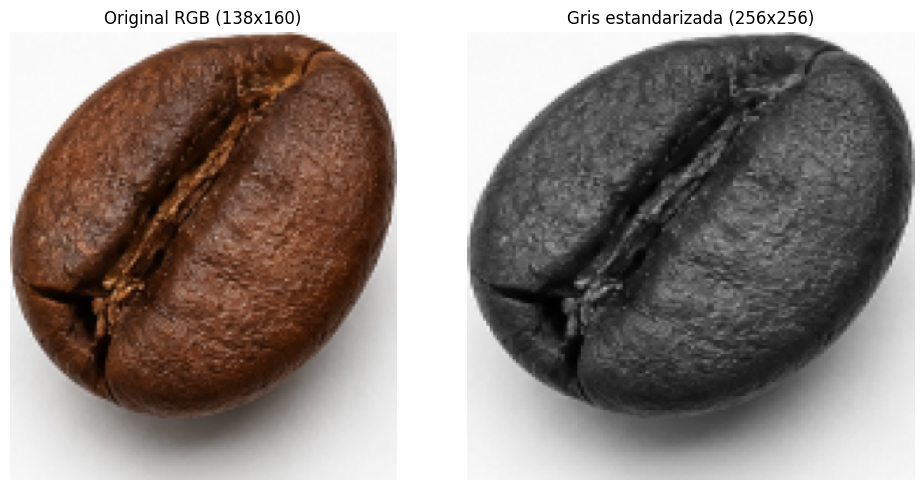

Se preprocesaron 17 imagenes a escala de grises 256x256.


In [4]:
ANCHO_ESTANDAR = 256  # TODO: ajustar según su dataset (resolucion de trabajo; mas grande = mas detalle pero mas lento)
ALTO_ESTANDAR = 256


def preprocesar_imagen(imagen_rgb, ancho=ANCHO_ESTANDAR, alto=ALTO_ESTANDAR):
    """Convierte a escala de grises y redimensiona a un tamano comun.
    Usamos cv2.INTER_AREA porque es la interpolacion recomendada por OpenCV
    cuando se reduce el tamano de una imagen (evita artefactos de aliasing)."""
    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    imagen_gris_reescalada = cv2.resize(imagen_gris, (ancho, alto), interpolation=cv2.INTER_AREA)
    return imagen_gris_reescalada


imagen_ejemplo_rgb = granos_sanos_recortados[0]
imagen_ejemplo_gris = preprocesar_imagen(imagen_ejemplo_rgb)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(imagen_ejemplo_rgb)
ejes[0].set_title(f"Original RGB ({imagen_ejemplo_rgb.shape[1]}x{imagen_ejemplo_rgb.shape[0]})")
ejes[0].axis("off")
ejes[1].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[1].set_title(f"Gris estandarizada ({ANCHO_ESTANDAR}x{ALTO_ESTANDAR})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

imagenes_gris = [preprocesar_imagen(imagen) for imagen in imagenes_dataset]
print(f"Se preprocesaron {len(imagenes_gris)} imagenes a escala de grises {ANCHO_ESTANDAR}x{ALTO_ESTANDAR}.")

## Seccion 5: Ajuste de brillo y contraste (con justificacion de parametros) — [SESION 1]

**Esta seccion es importante porque...** una camara de inspeccion real no
siempre entrega imagenes con un contraste ideal entre el objeto y el fondo;
saber ajustar brillo/contraste "a mano" ayuda a entender que hacen por
detras herramientas mas automaticas (como la ecualizacion de histograma).

**Aqui se realiza...** la transformacion lineal clasica `salida = alpha *
entrada + beta` sobre la imagen en escala de grises, usando
`cv2.convertScaleAbs` para evitar overflow de tipo `uint8`.

**Sirve para...** resaltar mejor el contorno del grano frente al fondo antes
de pasar a los filtros de ruido, bordes y segmentacion.

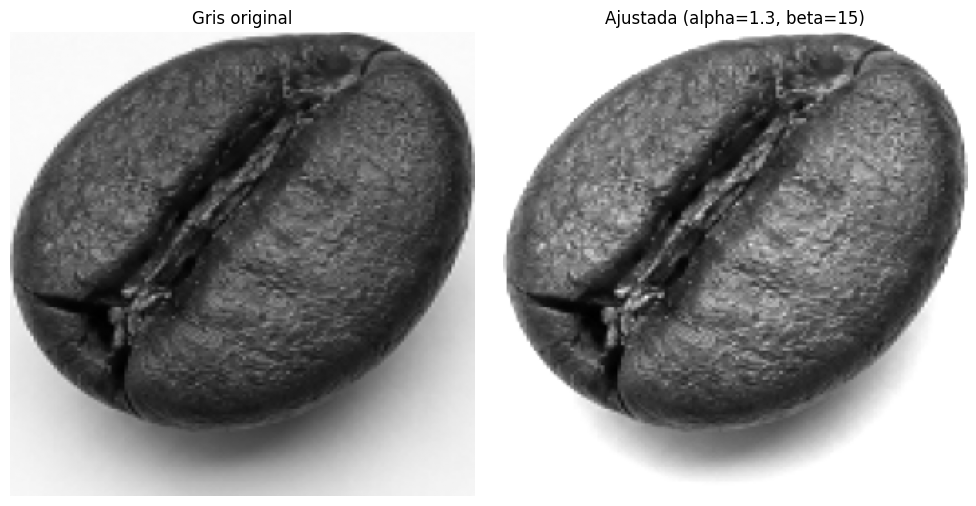

Justificacion: el fondo de nuestras fotos es claro y el grano tostado
es marron oscuro, por lo que ya hay bastante contraste natural; usamos
un alpha moderado (1.3) para acentuar un poco mas esa diferencia sin
quemar (saturar a 255) demasiados pixeles del fondo, y un beta pequenio
(+15) para compensar fotos ligeramente subexpuestas.


In [5]:
FACTOR_CONTRASTE_ALPHA = 1.3  # TODO: ajustar según su dataset (>1 aumenta el contraste, <1 lo reduce)
DESPLAZAMIENTO_BRILLO_BETA = 15  # TODO: ajustar según su dataset (suma directa al brillo; puede ser negativo)


def ajustar_brillo_contraste(imagen_gris, alpha=FACTOR_CONTRASTE_ALPHA, beta=DESPLAZAMIENTO_BRILLO_BETA):
    """
    Aplica la transformacion lineal de brillo/contraste: salida = alpha*entrada + beta.
    alpha controla el contraste (separa los tonos oscuros de los claros) y
    beta controla el brillo general (corrimiento aditivo). Usamos
    cv2.convertScaleAbs porque ya se encarga de saturar los valores fuera de
    [0, 255] en lugar de dejar que 'den la vuelta' (overflow silencioso de uint8).
    """
    return cv2.convertScaleAbs(imagen_gris, alpha=alpha, beta=beta)


imagen_ajustada = ajustar_brillo_contraste(imagen_ejemplo_gris)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[0].set_title("Gris original")
ejes[0].axis("off")
ejes[1].imshow(imagen_ajustada, cmap="gray")
ejes[1].set_title(f"Ajustada (alpha={FACTOR_CONTRASTE_ALPHA}, beta={DESPLAZAMIENTO_BRILLO_BETA})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

print("Justificacion: el fondo de nuestras fotos es claro y el grano tostado")
print("es marron oscuro, por lo que ya hay bastante contraste natural; usamos")
print("un alpha moderado (1.3) para acentuar un poco mas esa diferencia sin")
print("quemar (saturar a 255) demasiados pixeles del fondo, y un beta pequenio")
print("(+15) para compensar fotos ligeramente subexpuestas.")

## Seccion 6: Ruido y suavizado: comparar filtro gaussiano vs. mediana, justificar cual se usa — [SESION 1]

**Esta seccion es importante porque...** en un entorno industrial real las
imagenes casi nunca llegan perfectamente limpias (polvo en el lente, sensor
barato, vibracion de la banda transportadora), y el filtro elegido debe
ajustarse al tipo de ruido presente.

**Aqui se realiza...** se simula ruido tipo "sal y pimienta" sobre la imagen
de ejemplo (esto si se simula a proposito, es la forma estandar de probar un
filtro de suavizado) y se compara el resultado de suavizarla con un filtro
Gaussiano (`cv2.GaussianBlur`) contra un filtro de mediana (`cv2.medianBlur`).

**Sirve para...** justificar, con evidencia visual, que filtro conviene usar
antes de segmentar, ya que un suavizado mal elegido puede borrar bordes
importantes o dejar ruido residual que despues se cuenta como "objetos" falsos.

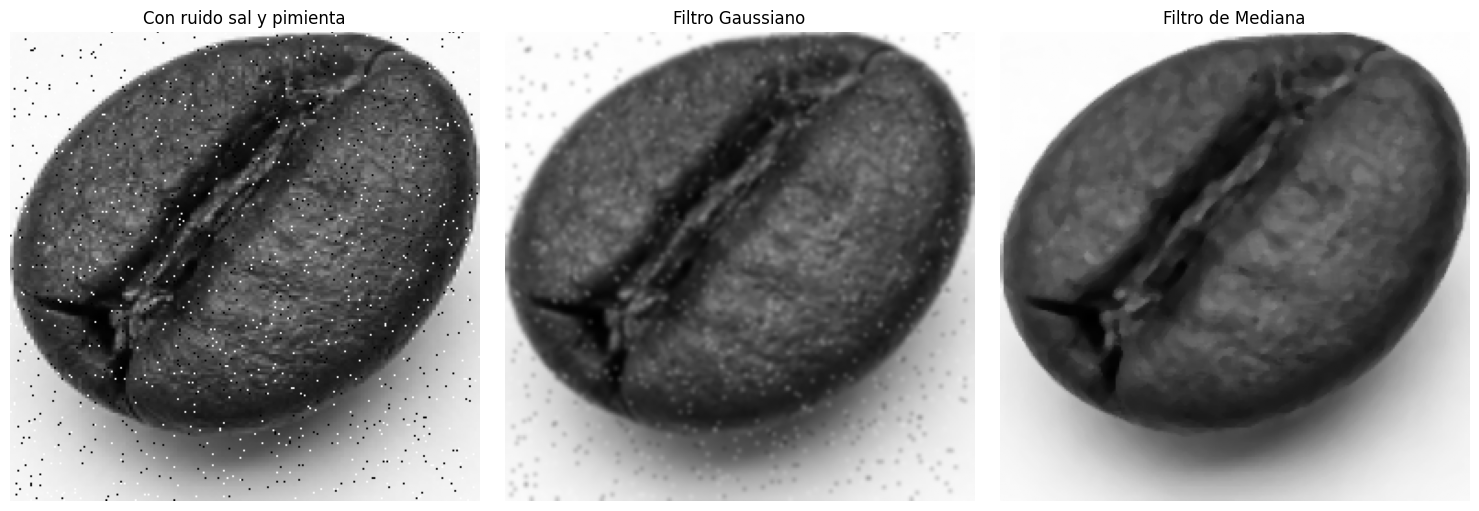

Justificacion: para ruido sal y pimienta el filtro de MEDIANA es mejor,
porque reemplaza cada pixel por el valor central (mediana) de su vecindad,
lo que elimina los valores extremos (0 y 255) sin promediarlos con el
resto. El filtro Gaussiano, en cambio, SI promedia esos extremos con sus
vecinos, dejando un halo borroso alrededor de cada pixel de ruido.
Por eso, para limpiar nuestras imagenes antes de segmentar, usaremos
cv2.medianBlur en el resto del notebook.


In [6]:
TAMANO_KERNEL_SUAVIZADO = 5  # TODO: ajustar según su dataset (debe ser impar; mas grande = mas suavizado)
CANTIDAD_RUIDO_SAL_PIMIENTA = 0.02  # TODO: ajustar según su dataset (proporcion de pixeles afectados)


def agregar_ruido_sal_pimienta(imagen_gris, cantidad=CANTIDAD_RUIDO_SAL_PIMIENTA, semilla=0):
    """Simulamos ruido tipo sal y pimienta (pixeles aislados en 0 o 255),
    comun en sensores baratos o con particulas de polvo, para poder poner a
    prueba los filtros de suavizado de forma controlada."""
    generador = np.random.RandomState(semilla)
    imagen_ruidosa = imagen_gris.copy()
    total_pixeles = imagen_gris.size
    num_pixeles_sal = int(cantidad * total_pixeles / 2)
    num_pixeles_pimienta = int(cantidad * total_pixeles / 2)

    coords_sal = [generador.randint(0, dimension, num_pixeles_sal) for dimension in imagen_gris.shape]
    imagen_ruidosa[coords_sal[0], coords_sal[1]] = 255

    coords_pimienta = [generador.randint(0, dimension, num_pixeles_pimienta) for dimension in imagen_gris.shape]
    imagen_ruidosa[coords_pimienta[0], coords_pimienta[1]] = 0

    return imagen_ruidosa


imagen_con_ruido = agregar_ruido_sal_pimienta(imagen_ejemplo_gris, semilla=SEMILLA_ALEATORIA)
imagen_filtro_gaussiano = cv2.GaussianBlur(imagen_con_ruido, (TAMANO_KERNEL_SUAVIZADO, TAMANO_KERNEL_SUAVIZADO), 0)
imagen_filtro_mediana = cv2.medianBlur(imagen_con_ruido, TAMANO_KERNEL_SUAVIZADO)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))
ejes[0].imshow(imagen_con_ruido, cmap="gray")
ejes[0].set_title("Con ruido sal y pimienta")
ejes[0].axis("off")
ejes[1].imshow(imagen_filtro_gaussiano, cmap="gray")
ejes[1].set_title("Filtro Gaussiano")
ejes[1].axis("off")
ejes[2].imshow(imagen_filtro_mediana, cmap="gray")
ejes[2].set_title("Filtro de Mediana")
ejes[2].axis("off")
plt.tight_layout()
plt.show()

print("Justificacion: para ruido sal y pimienta el filtro de MEDIANA es mejor,")
print("porque reemplaza cada pixel por el valor central (mediana) de su vecindad,")
print("lo que elimina los valores extremos (0 y 255) sin promediarlos con el")
print("resto. El filtro Gaussiano, en cambio, SI promedia esos extremos con sus")
print("vecinos, dejando un halo borroso alrededor de cada pixel de ruido.")
print("Por eso, para limpiar nuestras imagenes antes de segmentar, usaremos")
print("cv2.medianBlur en el resto del notebook.")

## Seccion 7: Histogramas comparados: normal vs. defecto (evaluar si ya se distinguen ahi) — [SESION 1]

**Esta seccion es importante porque...** antes de construir un pipeline de
segmentacion completo conviene preguntarse: ¿el histograma de intensidades,
por si solo, ya alcanza para distinguir un grano normal de uno defectuoso?
Si la respuesta es si, el problema seria mucho mas simple de lo que en
realidad es.

**Aqui se realiza...** el calculo y la graficacion del histograma de
intensidades (`np.histogram`) del grano sano de ejemplo y del grano real con
manchas de moho (`grano_cafe_defectuoso_20.png`).

**Sirve para...** justificar, con evidencia, por que en la Sesion 2 hace
falta analizar cada objeto de forma individual (area, forma) en lugar de
confiar solo en la distribucion global de intensidades de toda la imagen.

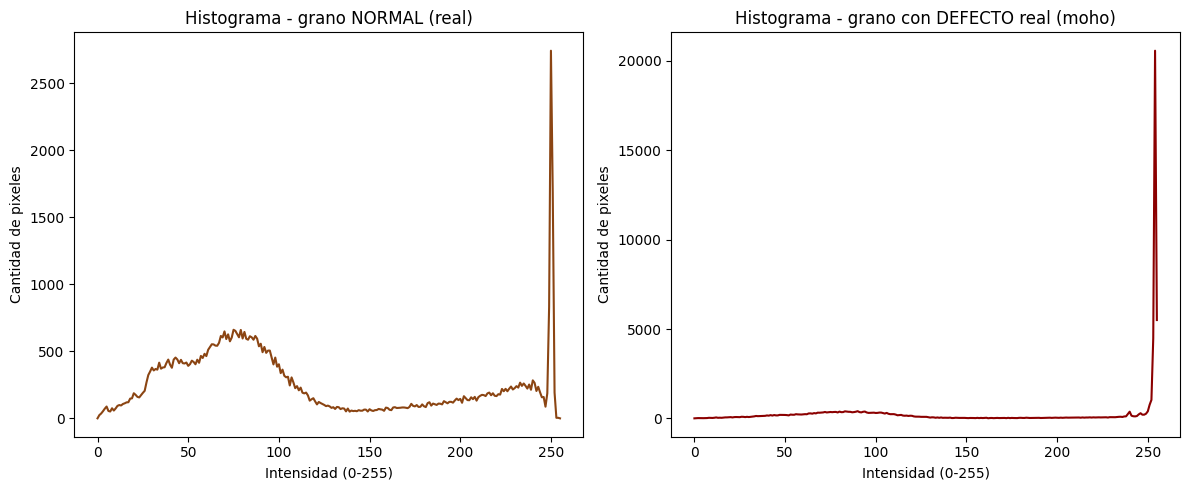

Observacion: las manchas de moho oscurecen zonas puntuales del grano,
lo que agrega mas peso en la zona de tonos oscuros del histograma del
grano defectuoso comparado con el sano. Sin embargo la diferencia no es
dramatica: un grano sano tambien tiene sombras y su propia grieta central
oscura, asi que el histograma GLOBAL por si solo NO alcanza para decidir
con confianza si hay un defecto. Por eso en la Sesion 2 analizaremos los
objetos de forma individual (area, forma) en lugar de solo la
distribucion global de intensidades de toda la imagen.


In [7]:
NUM_BINS_HISTOGRAMA = 256  # TODO: ajustar según su dataset (menos bins = histograma mas suave)


def calcular_histograma_gris(imagen_gris, num_bins=NUM_BINS_HISTOGRAMA):
    """Calcula el histograma de intensidades de una imagen en escala de grises."""
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=num_bins, range=(0, 256))
    return histograma, bordes


imagen_defecto_rgb = obtener_imagen_por_nombre(NOMBRE_GRANO_DEFECTO_COLOR)
imagen_defecto_gris = preprocesar_imagen(imagen_defecto_rgb)

histograma_normal, _ = calcular_histograma_gris(imagen_ejemplo_gris)
histograma_defecto, _ = calcular_histograma_gris(imagen_defecto_gris)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
ejes[0].plot(histograma_normal, color="saddlebrown")
ejes[0].set_title("Histograma - grano NORMAL (real)")
ejes[0].set_xlabel("Intensidad (0-255)")
ejes[0].set_ylabel("Cantidad de pixeles")
ejes[1].plot(histograma_defecto, color="darkred")
ejes[1].set_title("Histograma - grano con DEFECTO real (moho)")
ejes[1].set_xlabel("Intensidad (0-255)")
ejes[1].set_ylabel("Cantidad de pixeles")
plt.tight_layout()
plt.show()

print("Observacion: las manchas de moho oscurecen zonas puntuales del grano,")
print("lo que agrega mas peso en la zona de tonos oscuros del histograma del")
print("grano defectuoso comparado con el sano. Sin embargo la diferencia no es")
print("dramatica: un grano sano tambien tiene sombras y su propia grieta central")
print("oscura, asi que el histograma GLOBAL por si solo NO alcanza para decidir")
print("con confianza si hay un defecto. Por eso en la Sesion 2 analizaremos los")
print("objetos de forma individual (area, forma) en lugar de solo la")
print("distribucion global de intensidades de toda la imagen.")

## Seccion 8: Extraccion de bordes: Sobel — [SESION 1]

**Esta seccion es importante porque...** los bordes marcan la frontera entre
el objeto y el fondo (o entre distintas texturas dentro del objeto), y son la
base conceptual de la segmentacion que se vera en la Sesion 2.

**Aqui se realiza...** el calculo del gradiente en X y en Y con el operador
de Sobel (`cv2.Sobel`) y la combinacion de ambos en una magnitud de borde
normalizada a 8 bits.

**Sirve para...** visualizar donde estan los cambios de intensidad mas
fuertes del grano (su contorno externo y la grieta central), como paso
previo a comparar con Canny en la siguiente seccion.

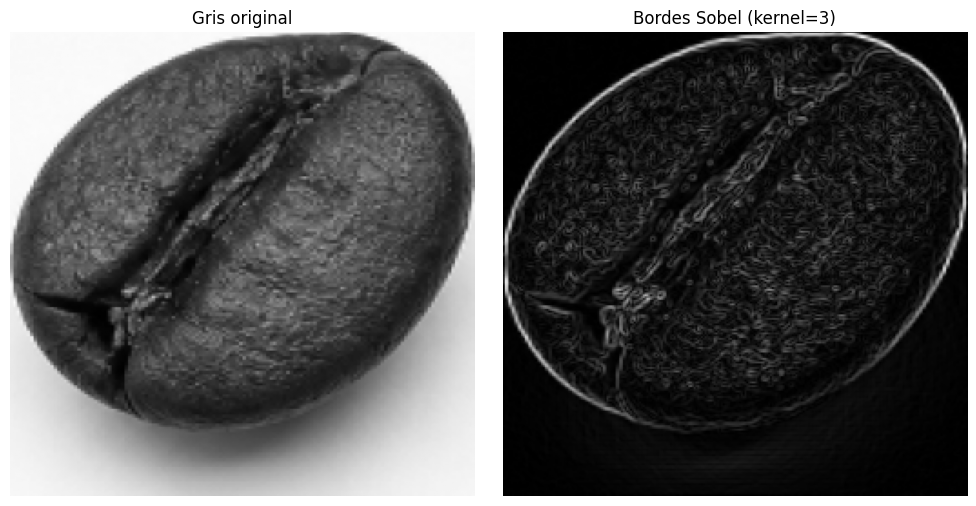

In [8]:
TAMANO_KERNEL_SOBEL = 3  # TODO: ajustar según su dataset (debe ser impar, tipicamente 3 o 5)


def extraer_bordes_sobel(imagen_gris, tamano_kernel=TAMANO_KERNEL_SOBEL):
    """Calcula el gradiente en X e Y con Sobel y combina sus magnitudes.
    Usamos CV_64F como tipo de salida intermedio para no perder los gradientes
    negativos (que se pierden si se usa directamente uint8)."""
    gradiente_x = cv2.Sobel(imagen_gris, cv2.CV_64F, 1, 0, ksize=tamano_kernel)
    gradiente_y = cv2.Sobel(imagen_gris, cv2.CV_64F, 0, 1, ksize=tamano_kernel)
    magnitud = np.sqrt(gradiente_x ** 2 + gradiente_y ** 2)
    magnitud_normalizada = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return magnitud_normalizada


bordes_sobel = extraer_bordes_sobel(imagen_ejemplo_gris)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[0].set_title("Gris original")
ejes[0].axis("off")
ejes[1].imshow(bordes_sobel, cmap="gray")
ejes[1].set_title(f"Bordes Sobel (kernel={TAMANO_KERNEL_SOBEL})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

## Seccion 9: Extraccion de bordes: Canny (probar y justificar el par de umbrales) — [SESION 1]

**Esta seccion es importante porque...** Canny es, en la practica, el
detector de bordes mas usado en sistemas de inspeccion reales porque combina
suavizado, deteccion de gradiente y un doble umbral con histeresis; pero su
resultado depende mucho de elegir bien ese par de umbrales.

**Aqui se realiza...** la comparacion de tres pares de umbrales
(bajo, alto) sobre la misma imagen usando `cv2.Canny`, para elegir el par que
mejor conserva el contorno externo del grano sin marcar demasiado ruido de
su textura interna.

**Sirve para...** dejar fijado el par de umbrales de Canny que usaremos como
referencia conceptual (aunque la segmentacion final del proyecto se hace por
umbralizacion, no por bordes, Canny ayuda a verificar visualmente que tan
"limpio" es el contorno del objeto).

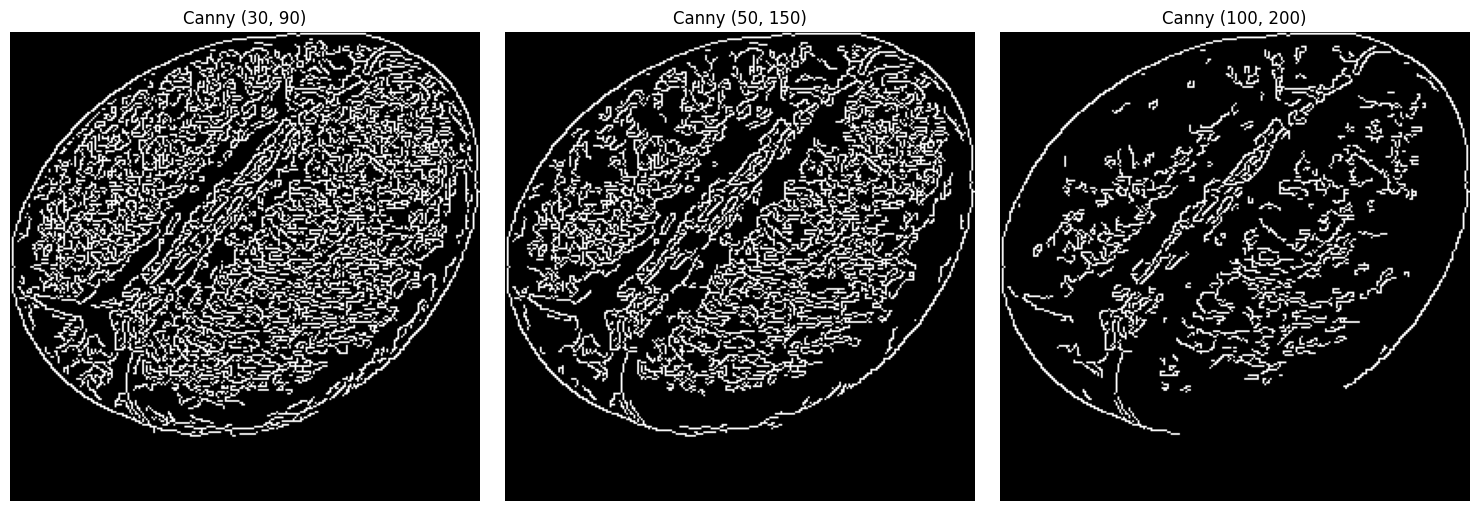

Justificacion: con (30, 90) aparece demasiado ruido de la textura interna
del grano (la piel tostada tambien se marca como bordes). Con (100, 200)
se pierde parte del contorno externo en las zonas donde la transicion
grano-fondo es mas suave. El par (50, 150) da el mejor
equilibrio: conserva el contorno externo casi completo (lo mas importante
para segmentar despues) y suprime la mayoria del ruido de textura interna.


In [9]:
UMBRAL_CANNY_BAJO = 50  # TODO: ajustar según su dataset
UMBRAL_CANNY_ALTO = 150  # TODO: ajustar según su dataset (regla practica: alto = 2 a 3 veces el bajo)


def extraer_bordes_canny(imagen_gris, umbral_bajo=UMBRAL_CANNY_BAJO, umbral_alto=UMBRAL_CANNY_ALTO):
    return cv2.Canny(imagen_gris, umbral_bajo, umbral_alto)


pares_umbrales_prueba = [(30, 90), (50, 150), (100, 200)]  # TODO: ajustar según su dataset (pares candidatos a comparar)

fig, ejes = plt.subplots(1, len(pares_umbrales_prueba), figsize=(5 * len(pares_umbrales_prueba), 5))
for eje, (umbral_bajo, umbral_alto) in zip(ejes, pares_umbrales_prueba):
    bordes = extraer_bordes_canny(imagen_ejemplo_gris, umbral_bajo, umbral_alto)
    eje.imshow(bordes, cmap="gray")
    eje.set_title(f"Canny ({umbral_bajo}, {umbral_alto})")
    eje.axis("off")
plt.tight_layout()
plt.show()

print("Justificacion: con (30, 90) aparece demasiado ruido de la textura interna")
print("del grano (la piel tostada tambien se marca como bordes). Con (100, 200)")
print("se pierde parte del contorno externo en las zonas donde la transicion")
print(f"grano-fondo es mas suave. El par ({UMBRAL_CANNY_BAJO}, {UMBRAL_CANNY_ALTO}) da el mejor")
print("equilibrio: conserva el contorno externo casi completo (lo mas importante")
print("para segmentar despues) y suprime la mayoria del ruido de textura interna.")

## Seccion 10: Segmentacion por umbral fijo — [SESION 2]

**Esta seccion es importante porque...** segmentar (separar el objeto del
fondo en una mascara binaria) es el paso que hace posible, mas adelante,
contar objetos y medir su area; es el corazon de todo el sistema de
inspeccion.

**Aqui se realiza...** una umbralizacion global con `cv2.threshold` usando un
unico valor fijo para toda la imagen, aplicada sobre una bandeja real con
varios granos de cafe (`14.png`): todo pixel mas oscuro que el umbral se
marca como objeto (255) y el resto como fondo (0).

**Sirve para...** obtener una primera mascara binaria simple y muy rapida de
calcular, que sera la base de la limpieza morfologica y el conteo de objetos
de las siguientes secciones.

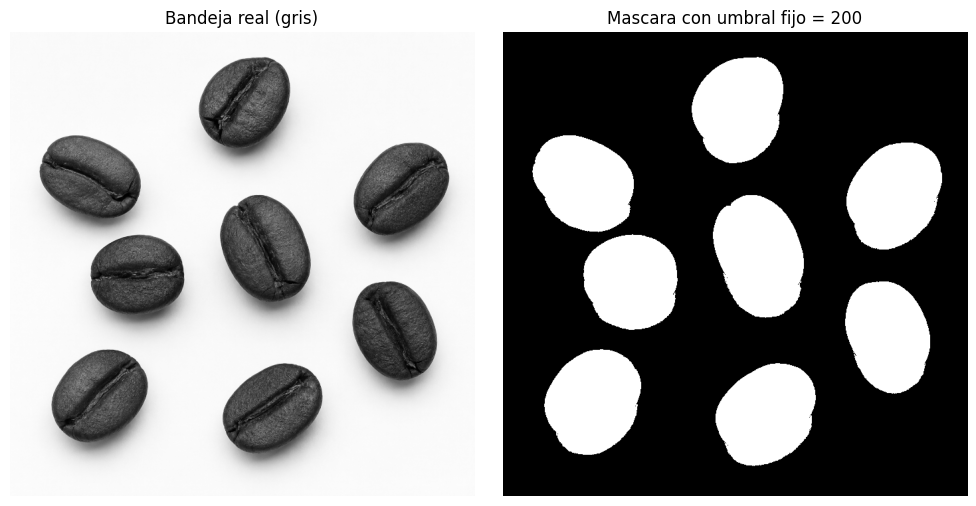

In [10]:
UMBRAL_FIJO = 200  # TODO: ajustar según su dataset (el fondo de nuestras fotos es claro, >200 en escala de grises)
NOMBRE_BANDEJA_A = "14.png"  # TODO: ajustar según su dataset (bandeja real: 8 granos)
LADO_CANVAS_BANDEJA = 700  # TODO: ajustar según su dataset (resolucion de trabajo para las bandejas)


def segmentar_umbral_fijo(imagen_gris, umbral=UMBRAL_FIJO):
    """El fondo de nuestras fotos es claro (>200 en escala de grises) y
    el objeto es mas oscuro que el fondo. Por eso usamos THRESH_BINARY_INV:
    todo lo que esta POR DEBAJO del umbral se marca como objeto (255 en la
    mascara), en lugar de al reves."""
    _, mascara = cv2.threshold(imagen_gris, umbral, 255, cv2.THRESH_BINARY_INV)
    return mascara


bandeja_a_rgb = cv2.resize(obtener_imagen_por_nombre(NOMBRE_BANDEJA_A), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
bandeja_a_gris = cv2.cvtColor(bandeja_a_rgb, cv2.COLOR_RGB2GRAY)
mascara_umbral_fijo = segmentar_umbral_fijo(bandeja_a_gris)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(bandeja_a_gris, cmap="gray")
ejes[0].set_title("Bandeja real (gris)")
ejes[0].axis("off")
ejes[1].imshow(mascara_umbral_fijo, cmap="gray")
ejes[1].set_title(f"Mascara con umbral fijo = {UMBRAL_FIJO}")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

## Seccion 11: Segmentacion adaptativa (comparar con la fija ante iluminacion no uniforme) — [SESION 2]

**Esta seccion es importante porque...** en una banda transportadora real la
iluminacion casi nunca es perfectamente uniforme (sombras, lamparas
desalineadas, reflejos), y un umbral global puede fallar justo en la zona mas
oscura o mas clara de la escena.

**Aqui se realiza...** en lugar de simular una sombra artificial, encontramos
en nuestro propio dataset una foto real con iluminacion despareja
(`7.jpg`, tiene una franja de sombra diagonal real causada por luz de
ventana) y comparamos sobre ELLA la mascara de umbral fijo contra la de
`cv2.adaptiveThreshold` (umbral local por vecindad).

**Sirve para...** justificar, con evidencia real (no simulada), cual metodo
de segmentacion conviene usar segun las condiciones de iluminacion del
dataset del grupo.

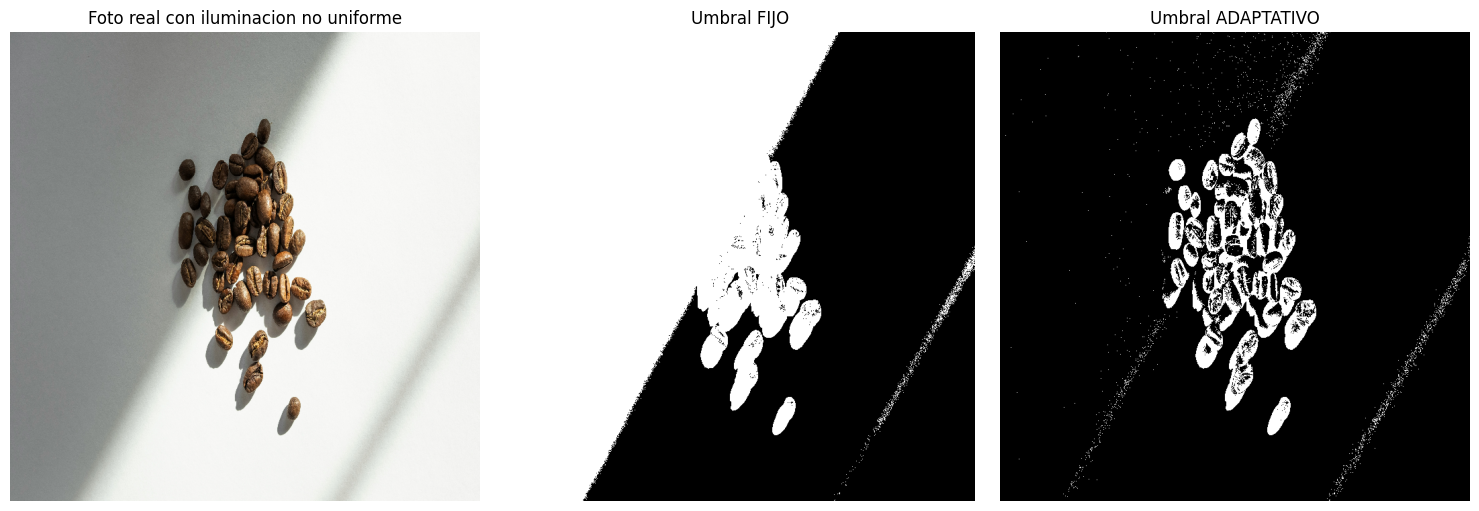

Area del blob mas grande con umbral FIJO: 238750 px^2
Area del blob mas grande con umbral ADAPTATIVO: 15378 px^2

Justificacion: en esta foto real, el umbral FIJO funde varios granos
con su sombra en un solo blob gigante, porque usa un unico valor global
para toda la imagen. El umbral ADAPTATIVO calcula un umbral local por
vecindad, por lo que separa mejor los granos individuales bajo la misma
iluminacion despareja (aunque deja algo mas de ruido fino, facil de
limpiar despues con morfologia). Para las bandejas del grupo con
iluminacion uniforme (Seccion 10) seguiremos usando umbral FIJO por ser
mas simple y rapido; dejamos el adaptativo documentado como la opcion
recomendada si el grupo trabajara con fotos de iluminacion despareja.


In [11]:
NOMBRE_FOTO_ILUMINACION_DESIGUAL = "7.jpg"  # TODO: ajustar según su dataset (foto real con sombra/luz despareja)

TAMANO_BLOQUE_ADAPTATIVO = 51  # TODO: ajustar según su dataset (impar; tamano de la ventana local)
CONSTANTE_C_ADAPTATIVO = 10  # TODO: ajustar según su dataset (resta fina al umbral local calculado)


def segmentar_umbral_adaptativo(imagen_gris, tamano_bloque=TAMANO_BLOQUE_ADAPTATIVO, constante_c=CONSTANTE_C_ADAPTATIVO):
    """A diferencia del umbral fijo, aqui cada pixel se compara contra el
    promedio (ponderado por una Gaussiana) de su propia vecindad, por lo que
    se adapta a cambios locales de iluminacion."""
    return cv2.adaptiveThreshold(
        imagen_gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, tamano_bloque, constante_c,
    )


imagen_sombra_rgb = cv2.resize(obtener_imagen_por_nombre(NOMBRE_FOTO_ILUMINACION_DESIGUAL), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
imagen_sombra_gris = cv2.cvtColor(imagen_sombra_rgb, cv2.COLOR_RGB2GRAY)

mascara_fija_sombra = segmentar_umbral_fijo(imagen_sombra_gris)
mascara_adaptativa_sombra = segmentar_umbral_adaptativo(imagen_sombra_gris)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))
ejes[0].imshow(imagen_sombra_rgb)
ejes[0].set_title("Foto real con iluminacion no uniforme")
ejes[0].axis("off")
ejes[1].imshow(mascara_fija_sombra, cmap="gray")
ejes[1].set_title("Umbral FIJO")
ejes[1].axis("off")
ejes[2].imshow(mascara_adaptativa_sombra, cmap="gray")
ejes[2].set_title("Umbral ADAPTATIVO")
ejes[2].axis("off")
plt.tight_layout()
plt.show()

# Contamos componentes conexos en cada mascara para evidenciar el problema:
# con la sombra real, el umbral fijo tiende a FUNDIR varios granos con la
# zona oscurecida del fondo en un solo blob gigante.
_, _, estadisticas_fija, _ = cv2.connectedComponentsWithStats(mascara_fija_sombra, connectivity=8)
_, _, estadisticas_adapt, _ = cv2.connectedComponentsWithStats(mascara_adaptativa_sombra, connectivity=8)
area_mayor_fija = estadisticas_fija[1:, cv2.CC_STAT_AREA].max() if len(estadisticas_fija) > 1 else 0
area_mayor_adapt = estadisticas_adapt[1:, cv2.CC_STAT_AREA].max() if len(estadisticas_adapt) > 1 else 0
print(f"Area del blob mas grande con umbral FIJO: {area_mayor_fija} px^2")
print(f"Area del blob mas grande con umbral ADAPTATIVO: {area_mayor_adapt} px^2")

print()
print("Justificacion: en esta foto real, el umbral FIJO funde varios granos")
print("con su sombra en un solo blob gigante, porque usa un unico valor global")
print("para toda la imagen. El umbral ADAPTATIVO calcula un umbral local por")
print("vecindad, por lo que separa mejor los granos individuales bajo la misma")
print("iluminacion despareja (aunque deja algo mas de ruido fino, facil de")
print("limpiar despues con morfologia). Para las bandejas del grupo con")
print("iluminacion uniforme (Seccion 10) seguiremos usando umbral FIJO por ser")
print("mas simple y rapido; dejamos el adaptativo documentado como la opcion")
print("recomendada si el grupo trabajara con fotos de iluminacion despareja.")

## Seccion 12: Limpieza morfologica (cierre morfologico) sobre la mascara binaria — [SESION 2]

**Esta seccion es importante porque...** una mascara binaria "cruda" casi
siempre tiene huequitos internos (por ejemplo, brillos especulares dentro del
objeto que quedaron mal segmentados) que, si no se corrigen, pueden hacer que
el conteo de componentes conexos de la siguiente seccion se equivoque.

**Aqui se realiza...** un cierre morfologico (`cv2.morphologyEx` con
`MORPH_CLOSE`, es decir, una dilatacion seguida de una erosion) sobre la
mascara obtenida en la Seccion 10 (bandeja real `14.png`).

**Sirve para...** dejar una mascara binaria "solida" (sin huecos internos)
lista para el conteo de objetos y la extraccion de rasgos por objeto.

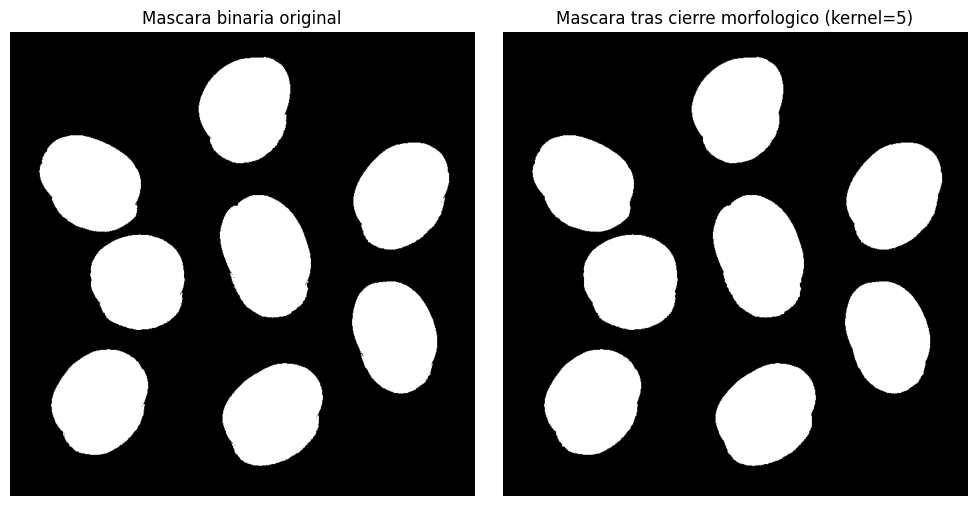

In [12]:
TAMANO_KERNEL_MORFOLOGICO = 5  # TODO: ajustar según su dataset (mas grande cierra huecos mas grandes, pero deforma mas el contorno)


def limpiar_mascara_morfologicamente(mascara, tamano_kernel=TAMANO_KERNEL_MORFOLOGICO):
    """
    El cierre morfologico (dilatacion seguida de erosion) rellena pequenios
    huecos internos sin cambiar demasiado el tamano externo del objeto. Usamos
    un kernel eliptico porque respeta mejor los contornos redondeados de un
    grano de cafe que un kernel rectangular.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamano_kernel, tamano_kernel))
    mascara_cerrada = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    return mascara_cerrada


mascara_limpia = limpiar_mascara_morfologicamente(mascara_umbral_fijo)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(mascara_umbral_fijo, cmap="gray")
ejes[0].set_title("Mascara binaria original")
ejes[0].axis("off")
ejes[1].imshow(mascara_limpia, cmap="gray")
ejes[1].set_title(f"Mascara tras cierre morfologico (kernel={TAMANO_KERNEL_MORFOLOGICO})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

## Seccion 13: Componentes conexos: conteo de objetos por imagen (validar contra conteo manual en al menos 3 imagenes) — [SESION 2]

**Esta seccion es importante porque...** contar objetos es uno de los dos
objetivos centrales del proyecto integrador (el otro es detectar defectos), y
`cv2.connectedComponentsWithStats` es la herramienta clasica para hacerlo a
partir de una mascara binaria.

**Aqui se realiza...** aplicamos el pipeline de segmentacion + limpieza +
componentes conexos sobre **tres fotos reales** de nuestro dataset que
efectivamente traen varios granos de cafe ya separados sobre fondo claro
(`14.png`, `15.png` y `2.jpg`), y comparamos el conteo automatico contra el
conteo manual que hicimos nosotros mismos mirando cada foto.

**Sirve para...** validar que el pipeline de segmentacion + limpieza +
componentes conexos cuenta correctamente el numero de objetos presentes en
una escena real, antes de usarlo para extraer rasgos y detectar defectos.

14.png: conteo manual=8, el algoritmo conto 8 -> OK
15.png: conteo manual=8, el algoritmo conto 8 -> OK
2.jpg: conteo manual=19, el algoritmo conto 19 -> OK


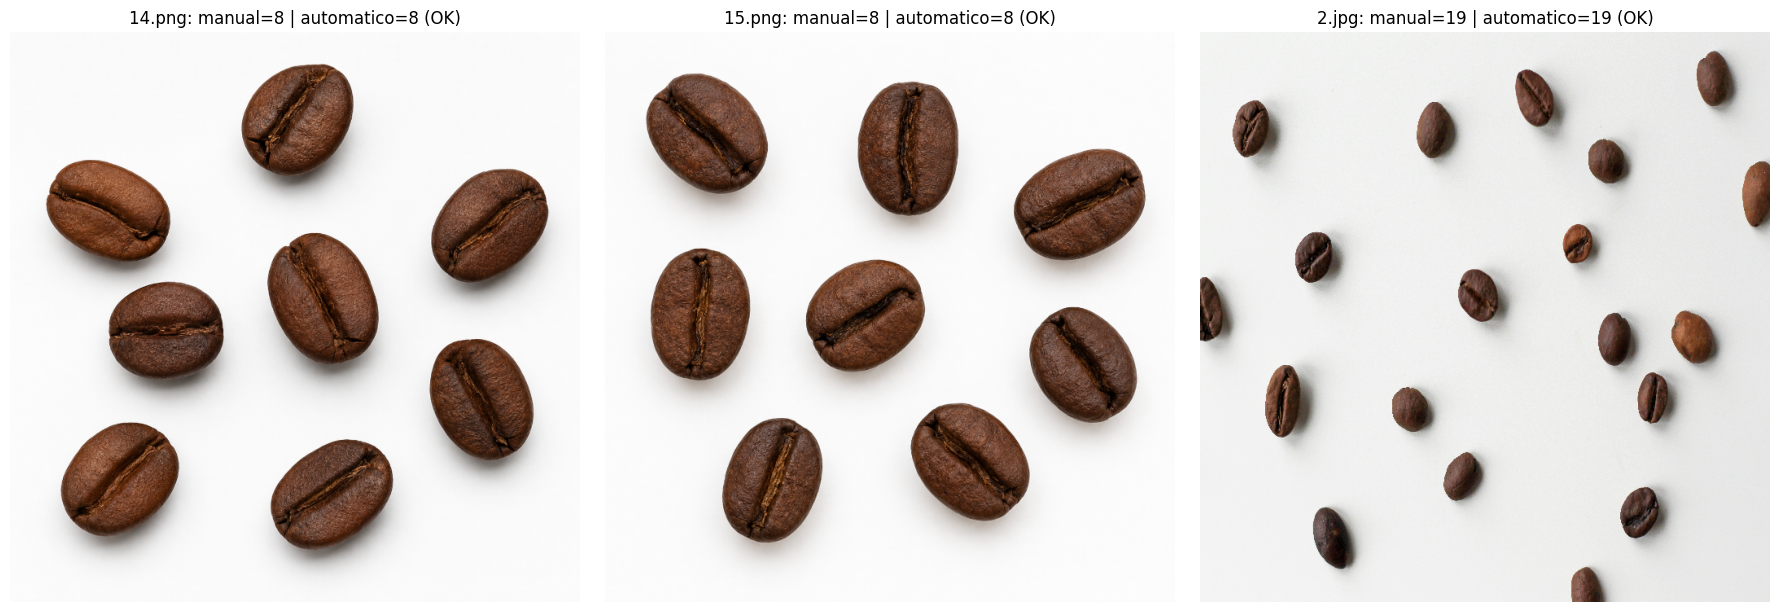

In [13]:
AREA_MINIMA_OBJETO = 500  # TODO: ajustar según su dataset (px^2 minimos para contar algo como objeto real y no ruido)

# Las 3 bandejas reales elegidas y su conteo MANUAL (lo contamos nosotros a ojo
# mirando cada foto antes de correr el algoritmo).
NOMBRES_BANDEJAS_VALIDACION = ["14.png", "15.png", "2.jpg"]  # TODO: ajustar según su dataset
CONTEOS_MANUALES = {"14.png": 8, "15.png": 8, "2.jpg": 19}  # TODO: ajustar según su dataset (conteo manual real)


def segmentar_y_contar_objetos(imagen_rgb, umbral=UMBRAL_FIJO, tamano_kernel_morfologico=TAMANO_KERNEL_MORFOLOGICO,
                                area_minima=AREA_MINIMA_OBJETO):
    """Pipeline completo de segmentacion + limpieza + componentes conexos.
    area_minima descarta manchitas de ruido demasiado pequenias para ser un
    objeto real (por ejemplo, restos de la mascara que sobrevivieron al cierre
    morfologico)."""
    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    mascara = segmentar_umbral_fijo(imagen_gris, umbral)
    mascara = limpiar_mascara_morfologicamente(mascara, tamano_kernel_morfologico)
    num_etiquetas, etiquetas, estadisticas, centroides = cv2.connectedComponentsWithStats(mascara, connectivity=8)

    objetos_validos = [
        etiqueta for etiqueta in range(1, num_etiquetas)  # la etiqueta 0 es el fondo, se descarta
        if estadisticas[etiqueta, cv2.CC_STAT_AREA] >= area_minima
    ]
    return mascara, etiquetas, estadisticas, centroides, objetos_validos


fig, ejes = plt.subplots(1, len(NOMBRES_BANDEJAS_VALIDACION), figsize=(6 * len(NOMBRES_BANDEJAS_VALIDACION), 6))
for columna, nombre_bandeja in enumerate(NOMBRES_BANDEJAS_VALIDACION):
    bandeja_rgb = cv2.resize(obtener_imagen_por_nombre(nombre_bandeja), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
    _, _, _, _, objetos_validos = segmentar_y_contar_objetos(bandeja_rgb)
    conteo_automatico = len(objetos_validos)
    conteo_manual = CONTEOS_MANUALES[nombre_bandeja]
    coincide = "OK" if conteo_automatico == conteo_manual else "DIFIERE"

    ejes[columna].imshow(bandeja_rgb)
    ejes[columna].set_title(f"{nombre_bandeja}: manual={conteo_manual} | automatico={conteo_automatico} ({coincide})")
    ejes[columna].axis("off")
    print(f"{nombre_bandeja}: conteo manual={conteo_manual}, el algoritmo conto {conteo_automatico} -> {coincide}")

plt.tight_layout()
plt.show()

## Seccion 14: Extraccion de rasgos por objeto: area y relacion de aspecto (forma) — [SESION 2]

**Esta seccion es importante porque...** para poder decidir despues cual
objeto es "normal" y cual es "defectuoso" primero hay que medir algo de cada
objeto por separado; el area y la relacion de aspecto son los rasgos mas
simples y directos que entrega `cv2.connectedComponentsWithStats`.

**Aqui se realiza...** tomamos la bandeja real `14.png` (8 granos sanos,
validada en la Seccion 13) y le insertamos, en una esquina vacia, UN grano
real con dano fisico fotografiado (`grano_cafe_defectuoso_01.png`, el mismo
de la Seccion 3), reescalado para representar un fragmento incompleto. Esta
es la **unica composicion** de todo el pipeline principal, y la hacemos
porque ninguna foto de nuestro dataset trae, de forma natural, una bandeja
con un grano roto entre varios sanos. Con esta bandeja de 9 objetos (8 reales
+ 1 real insertado) calculamos area y relacion de aspecto de cada uno.

**Sirve para...** dejar preparada la tabla de rasgos por objeto que se usara
en la Seccion 15 para calcular el z-score del area y decidir cuales objetos
son anomalos.

Objetos detectados en la bandeja con el grano insertado: 9 (esperado: 9)
Objeto  Area (px^2)    Relacion aspecto  
0       17083          0.86              
1       16765          1.05              
2       17542          0.89              
3       19138          0.74              
4       16284          0.99              
5       16568          0.76              
6       17478          0.92              
7       17533          0.97              
8       4511           1.04              


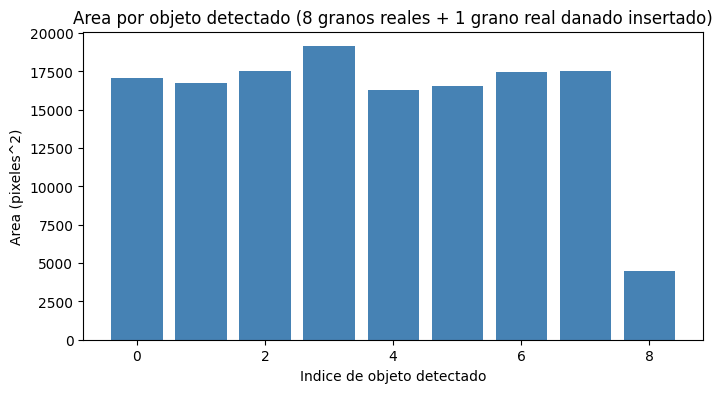

In [14]:
NOMBRE_GRANO_A_INSERTAR = "grano_cafe_defectuoso_01.png"  # TODO: ajustar según su dataset (grano real danado a insertar)
POSICION_INSERCION = (600, 600)  # TODO: ajustar según su dataset (esquina vacia de la bandeja, en pixeles)
FACTOR_ESCALA_FRAGMENTO = 0.55  # TODO: ajustar según su dataset (que tan chico queda el fragmento insertado)


def extraer_silueta_objeto(imagen_rgb, ancho_objetivo=140):
    """
    Recorta el objeto principal de una foto individual (fondo claro) usando
    un umbral fijo + el bounding box de su contorno mas grande, y lo reescala
    a un ancho de trabajo comun. Si no se encuentra ningun contorno (por
    ejemplo, al usar el dataset de respaldo de skimage con fondos no
    uniformes), devolvemos la imagen completa sin recortar para que el resto
    del pipeline no se rompa.
    """
    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    mascara = limpiar_mascara_morfologicamente(segmentar_umbral_fijo(imagen_gris))
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contornos) == 0:
        recorte_rgb = cv2.resize(imagen_rgb, (ancho_objetivo, ancho_objetivo), interpolation=cv2.INTER_AREA)
        recorte_mascara = np.full(recorte_rgb.shape[:2], 255, dtype=np.uint8)
        return recorte_rgb, recorte_mascara

    contorno_mayor = max(contornos, key=cv2.contourArea)
    x, y, ancho_caja, alto_caja = cv2.boundingRect(contorno_mayor)
    recorte_rgb = imagen_rgb[y:y + alto_caja, x:x + ancho_caja]
    recorte_mascara = mascara[y:y + alto_caja, x:x + ancho_caja]

    escala = ancho_objetivo / ancho_caja
    nuevo_alto = max(1, int(alto_caja * escala))
    recorte_rgb = cv2.resize(recorte_rgb, (ancho_objetivo, nuevo_alto), interpolation=cv2.INTER_AREA)
    recorte_mascara = cv2.resize(recorte_mascara, (ancho_objetivo, nuevo_alto), interpolation=cv2.INTER_NEAREST)
    return recorte_rgb, recorte_mascara


def insertar_grano_real_danado(bandeja_rgb, nombre_grano_danado, posicion_xy, factor_escala=FACTOR_ESCALA_FRAGMENTO):
    """
    Pega, sobre una COPIA de la bandeja real, un grano con dano real
    fotografiado (no dibujado), reescalado hacia abajo para representar un
    fragmento incompleto. Reescalamos porque el area de un grano mordido, tal
    cual, no siempre difiere lo suficiente del area de un grano sano como para
    que el z-score la detecte (la muesca es pequenia frente al tamanio total
    del grano) asi que exageramos el tamanio para simular que el fragmento se
    partio en un pedazo mas chico. Esta es la unica composicion del pipeline
    principal, y queda documentada aqui de forma explicita.
    """
    bandeja_con_insercion = bandeja_rgb.copy()
    imagen_grano_danado = obtener_imagen_por_nombre(nombre_grano_danado)
    recorte_rgb, recorte_mascara = extraer_silueta_objeto(imagen_grano_danado, ancho_objetivo=140)

    nuevo_ancho = max(10, int(recorte_rgb.shape[1] * factor_escala))
    nuevo_alto = max(10, int(recorte_rgb.shape[0] * factor_escala))
    recorte_rgb = cv2.resize(recorte_rgb, (nuevo_ancho, nuevo_alto))
    recorte_mascara = cv2.resize(recorte_mascara, (nuevo_ancho, nuevo_alto))

    centro_x, centro_y = posicion_xy
    x0 = centro_x - nuevo_ancho // 2
    y0 = centro_y - nuevo_alto // 2
    region_objeto = recorte_mascara > 0
    bandeja_con_insercion[y0:y0 + nuevo_alto, x0:x0 + nuevo_ancho][region_objeto] = recorte_rgb[region_objeto]
    return bandeja_con_insercion


def extraer_rasgos_objetos(estadisticas, objetos_validos):
    """Para cada objeto valido devuelve su area, su bounding box y su
    relacion de aspecto (ancho/alto). La relacion de aspecto es util porque
    una pieza rota o deformada suele cambiar de forma ademas de tamano."""
    rasgos = []
    for etiqueta in objetos_validos:
        x = estadisticas[etiqueta, cv2.CC_STAT_LEFT]
        y = estadisticas[etiqueta, cv2.CC_STAT_TOP]
        ancho = estadisticas[etiqueta, cv2.CC_STAT_WIDTH]
        alto = estadisticas[etiqueta, cv2.CC_STAT_HEIGHT]
        area = estadisticas[etiqueta, cv2.CC_STAT_AREA]
        relacion_aspecto = ancho / alto if alto > 0 else 0
        rasgos.append({
            "etiqueta": etiqueta, "x": x, "y": y, "w": ancho, "h": alto,
            "area": area, "relacion_aspecto": relacion_aspecto,
        })
    return rasgos


bandeja_analisis = insertar_grano_real_danado(bandeja_a_rgb, NOMBRE_GRANO_A_INSERTAR, POSICION_INSERCION)
mascara_analisis, etiquetas_analisis, estadisticas_analisis, centroides_analisis, objetos_validos_analisis = (
    segmentar_y_contar_objetos(bandeja_analisis)
)
rasgos_bandeja = extraer_rasgos_objetos(estadisticas_analisis, objetos_validos_analisis)

print(f"Objetos detectados en la bandeja con el grano insertado: {len(rasgos_bandeja)} (esperado: 9)")
print(f"{'Objeto':<8}{'Area (px^2)':<15}{'Relacion aspecto':<18}")
for indice, rasgo in enumerate(rasgos_bandeja):
    print(f"{indice:<8}{rasgo['area']:<15}{rasgo['relacion_aspecto']:<18.2f}")

areas_objetos = np.array([rasgo["area"] for rasgo in rasgos_bandeja])
plt.figure(figsize=(8, 4))
plt.bar(range(len(areas_objetos)), areas_objetos, color="steelblue")
plt.xlabel("Indice de objeto detectado")
plt.ylabel("Area (pixeles^2)")
plt.title("Area por objeto detectado (8 granos reales + 1 grano real danado insertado)")
plt.show()

## Seccion 15: Deteccion de anomalias por z-score sobre el area (umbral Z ajustable) — [SESION 2]

**Esta seccion es importante porque...** es el corazon estadistico del
sistema de inspeccion: convierte una medida (el area de cada objeto) en una
decision binaria (OK / DEFECTO) de forma automatica y ajustable.

**Aqui se realiza...** el calculo del z-score del area de cada objeto
respecto a la media y desviacion estandar del area de todos los objetos de la
**misma** bandeja, y se marca como anomalia todo objeto cuyo `|z| > umbral_z`.

**Sirve para...** identificar automaticamente, dentro de una escena con
varios objetos del mismo tipo, cual de ellos tiene un tamano
"estadisticamente distinto" al resto (en nuestro caso, el grano real danado
que insertamos en la Seccion 14), sin necesidad de fijar un area
minima/maxima absoluta a mano.

In [15]:
UMBRAL_Z_SCORE = 1.5  # TODO: ajustar según su dataset (mas bajo = deteccion mas sensible, pero con mas falsos positivos)


def detectar_anomalias_zscore(rasgos_objetos, umbral_z=UMBRAL_Z_SCORE):
    """
    Calcula el z-score del area de cada objeto respecto a la media y
    desviacion estandar del area de todos los objetos de la MISMA imagen:

        z = (area_objeto - area_promedio) / desviacion_estandar_area

    Un area demasiado chica o demasiado grande respecto al resto (|z| >
    umbral_z) se marca como anomalia (posible pieza rota, incompleta, o un
    objeto que no deberia estar ahi).
    """
    areas = np.array([rasgo["area"] for rasgo in rasgos_objetos], dtype=np.float64)
    area_promedio = areas.mean()
    desviacion_area = areas.std()

    for rasgo in rasgos_objetos:
        if desviacion_area > 0:
            z_score = (rasgo["area"] - area_promedio) / desviacion_area
        else:
            z_score = 0.0  # si todas las areas son identicas, no hay anomalia posible
        rasgo["z_score_area"] = z_score
        rasgo["es_defecto"] = abs(z_score) > umbral_z

    return rasgos_objetos


rasgos_bandeja = detectar_anomalias_zscore(rasgos_bandeja)

print(f"{'Objeto':<8}{'Area':<10}{'Z-score':<12}{'Diagnostico':<12}")
for indice, rasgo in enumerate(rasgos_bandeja):
    diagnostico = "DEFECTO" if rasgo["es_defecto"] else "OK"
    print(f"{indice:<8}{rasgo['area']:<10}{rasgo['z_score_area']:<12.2f}{diagnostico:<12}")

Objeto  Area      Z-score     Diagnostico 
0       17083     0.29        OK          
1       16765     0.22        OK          
2       17542     0.41        OK          
3       19138     0.80        OK          
4       16284     0.10        OK          
5       16568     0.17        OK          
6       17478     0.39        OK          
7       17533     0.40        OK          
8       4511      -2.78       DEFECTO     


## Seccion 16: Reporte final de inspeccion: visualizacion con cada objeto marcado OK (verde) / DEFECTO (rojo) — [SESION 2]

**Esta seccion es importante porque...** un sistema de inspeccion visual solo
es util si su resultado se puede comunicar de forma clara e inmediata a una
persona; un reporte visual con colores es mucho mas rapido de interpretar que
una tabla de numeros.

**Aqui se realiza...** el dibujo de un rectangulo verde sobre cada objeto
marcado como OK y uno rojo sobre cada objeto marcado como DEFECTO (segun el
z-score de la Seccion 15), junto con su valor de z-score.

**Sirve para...** entregar el resultado final del pipeline completo del
proyecto: contar los objetos de una escena y marcar automaticamente cuales
presentan un defecto.

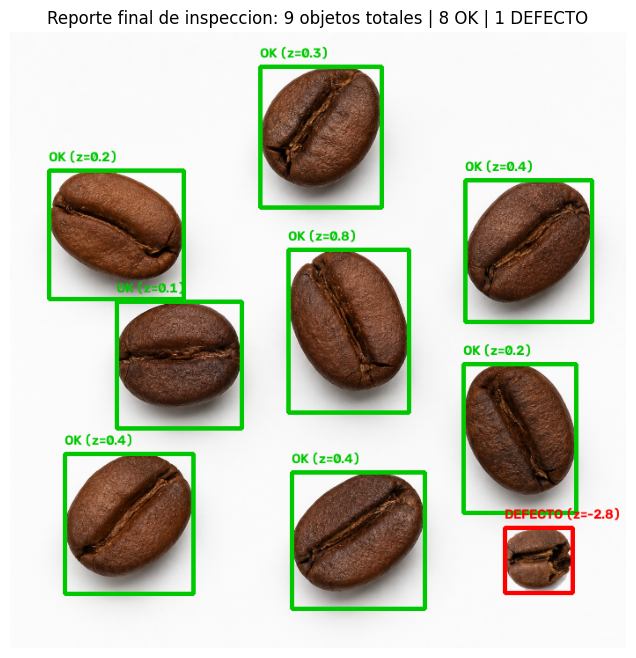

RESUMEN DE INSPECCION
  Objetos detectados: 9
  OK: 8
  DEFECTO: 1


In [16]:
def generar_reporte_visual(imagen_rgb, rasgos_objetos):
    """Dibuja un rectangulo verde sobre los objetos OK y uno rojo sobre los
    marcados como defecto, junto con su z-score, para el reporte final de
    inspeccion."""
    imagen_reporte = imagen_rgb.copy()
    for rasgo in rasgos_objetos:
        color = (255, 0, 0) if rasgo["es_defecto"] else (0, 200, 0)
        etiqueta_texto = "DEFECTO" if rasgo["es_defecto"] else "OK"
        cv2.rectangle(
            imagen_reporte, (rasgo["x"], rasgo["y"]),
            (rasgo["x"] + rasgo["w"], rasgo["y"] + rasgo["h"]), color, 3,
        )
        cv2.putText(
            imagen_reporte, f"{etiqueta_texto} (z={rasgo['z_score_area']:.1f})",
            (rasgo["x"], max(20, rasgo["y"] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2,
        )
    return imagen_reporte


reporte_final = generar_reporte_visual(bandeja_analisis, rasgos_bandeja)

num_objetos_ok = sum(1 for rasgo in rasgos_bandeja if not rasgo["es_defecto"])
num_objetos_defecto = sum(1 for rasgo in rasgos_bandeja if rasgo["es_defecto"])

plt.figure(figsize=(10, 8))
plt.imshow(reporte_final)
plt.title(
    f"Reporte final de inspeccion: {len(rasgos_bandeja)} objetos totales | "
    f"{num_objetos_ok} OK | {num_objetos_defecto} DEFECTO"
)
plt.axis("off")
plt.show()

print("RESUMEN DE INSPECCION")
print(f"  Objetos detectados: {len(rasgos_bandeja)}")
print(f"  OK: {num_objetos_ok}")
print(f"  DEFECTO: {num_objetos_defecto}")

## Seccion 17: Simulacion de banda transportadora: desplazar UNA foto con cv2.warpAffine generando 4-5 fotogramas — [BONUS]

**Esta seccion es importante porque...** un sistema de inspeccion real no
analiza fotos aisladas: analiza un video (una secuencia de fotogramas) de
objetos pasando frente a una camara fija sobre una banda transportadora.

**Aqui se realiza...** a partir de UNA sola foto real de un grano sano
(recortado de `14.png`), se generan varios fotogramas desplazandola
horizontalmente con una matriz de traslacion aplicada mediante
`cv2.warpAffine`, simulando el movimiento de un objeto sobre una banda. Esta
es la simulacion que la guia de la materia pide explicitamente para el
bonus, a diferencia del resto del pipeline principal que ya usamos con datos
100% reales.

**Sirve para...** tener una mini-secuencia de video sintetica sobre la cual
probar, en las siguientes secciones bonus, deteccion de centroides y tracking
por fotograma.

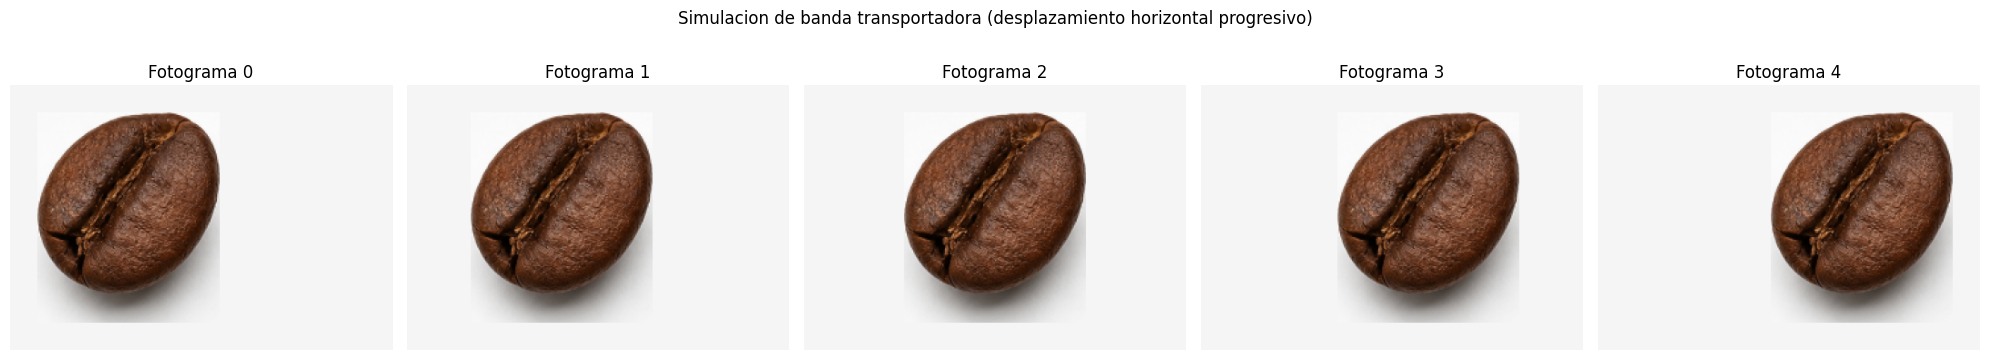

In [17]:
NUM_FOTOGRAMAS_SIMULACION = 5  # TODO: ajustar según su dataset (4 o 5 fotogramas, segun pide la guia)
DESPLAZAMIENTO_PX_POR_FOTOGRAMA = 40  # TODO: ajustar según su dataset (simula la velocidad de la banda)


def generar_fotogramas_banda(imagen_rgb, num_fotogramas=NUM_FOTOGRAMAS_SIMULACION,
                              desplazamiento_px=DESPLAZAMIENTO_PX_POR_FOTOGRAMA):
    """
    A partir de UNA sola foto, generamos varios fotogramas desplazando el
    contenido horizontalmente con una matriz de traslacion 2x3 (warpAffine),
    para simular como se veria un mismo objeto pasando por una banda
    transportadora frente a una camara fija.
    """
    alto, ancho = imagen_rgb.shape[:2]
    fotogramas = []
    for indice_fotograma in range(num_fotogramas):
        desplazamiento_x = indice_fotograma * desplazamiento_px
        matriz_traslacion = np.float32([[1, 0, desplazamiento_x], [0, 1, 0]])
        fotograma = cv2.warpAffine(
            imagen_rgb, matriz_traslacion, (ancho, alto), borderValue=(245, 245, 245)
        )
        fotogramas.append(fotograma)
    return fotogramas


imagen_base_banda_rgb, _ = extraer_silueta_objeto(granos_sanos_recortados[0], ancho_objetivo=200)
# Pegamos el grano recortado sobre un lienzo mas grande para tener espacio de sobra al
# desplazarlo (el alto del lienzo se calcula a partir del alto real del grano recortado,
# que no siempre es exactamente cuadrado, para evitar que la pegada se salga del lienzo).
alto_grano, ancho_grano = imagen_base_banda_rgb.shape[:2]
margen = 30
desplazamiento_total_maximo = (NUM_FOTOGRAMAS_SIMULACION - 1) * DESPLAZAMIENTO_PX_POR_FOTOGRAMA
lienzo_base = np.full(
    (alto_grano + 2 * margen, ancho_grano + desplazamiento_total_maximo + 2 * margen, 3),
    245, dtype=np.uint8,
)
lienzo_base[margen:margen + alto_grano, margen:margen + ancho_grano] = imagen_base_banda_rgb
imagen_base_banda = lienzo_base

fotogramas_banda = generar_fotogramas_banda(imagen_base_banda)

fig, ejes = plt.subplots(1, len(fotogramas_banda), figsize=(4 * len(fotogramas_banda), 4))
for indice_fotograma, (eje, fotograma) in enumerate(zip(ejes, fotogramas_banda)):
    eje.imshow(fotograma)
    eje.set_title(f"Fotograma {indice_fotograma}")
    eje.axis("off")
plt.suptitle("Simulacion de banda transportadora (desplazamiento horizontal progresivo)")
plt.tight_layout()
plt.show()

## Seccion 18: Deteccion de centroides por fotograma (reutilizando la funcion de segmentacion de la Seccion 10-13) — [BONUS]

**Esta seccion es importante porque...** para poder rastrear un objeto entre
fotogramas primero hay que reducirlo a un punto representativo (su centroide)
en cada uno de ellos; es el mismo pipeline de segmentacion ya construido, solo
que aplicado fotograma por fotograma.

**Aqui se realiza...** la reutilizacion de `segmentar_y_contar_objetos` (de la
Seccion 13) sobre cada fotograma de la simulacion de banda transportadora,
extrayendo el centroide de cada objeto detectado con
`cv2.connectedComponentsWithStats`.

**Sirve para...** obtener, para cada fotograma, la lista de posiciones (x, y)
de los objetos detectados, que es la entrada que necesita el tracker de la
siguiente seccion.

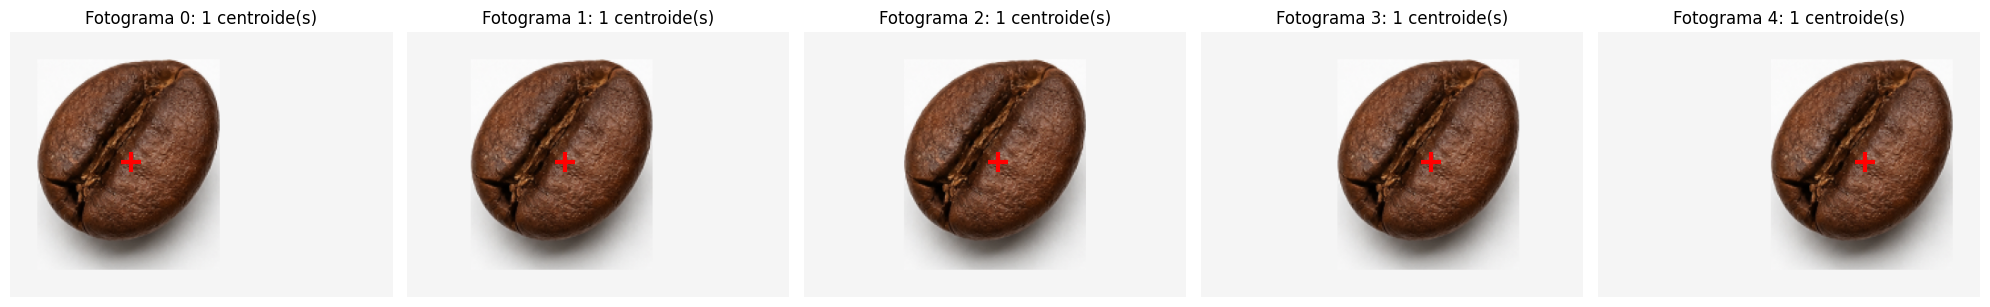

In [18]:
AREA_MINIMA_FOTOGRAMA = 300  # TODO: ajustar según su dataset (px^2 minimos; el lienzo del grano es mas chico que una bandeja)


def detectar_centroides_fotograma(imagen_rgb, umbral=UMBRAL_FIJO, area_minima=AREA_MINIMA_FOTOGRAMA):
    """Reutiliza el pipeline de segmentacion + componentes conexos de la
    Sesion 2 (Secciones 10 a 13) para obtener los centroides de los objetos
    detectados en un fotograma de la banda transportadora."""
    _, _, _, centroides, objetos_validos = segmentar_y_contar_objetos(
        imagen_rgb, umbral=umbral, area_minima=area_minima
    )
    centroides_validos = [tuple(centroides[etiqueta]) for etiqueta in objetos_validos]
    return centroides_validos


centroides_por_fotograma = [detectar_centroides_fotograma(fotograma) for fotograma in fotogramas_banda]

fig, ejes = plt.subplots(1, len(fotogramas_banda), figsize=(4 * len(fotogramas_banda), 4))
for indice_fotograma, (eje, fotograma, centroides) in enumerate(
    zip(ejes, fotogramas_banda, centroides_por_fotograma)
):
    eje.imshow(fotograma)
    for centro_x, centro_y in centroides:
        eje.plot(centro_x, centro_y, "r+", markersize=15, markeredgewidth=3)
    eje.set_title(f"Fotograma {indice_fotograma}: {len(centroides)} centroide(s)")
    eje.axis("off")
plt.tight_layout()
plt.show()

## Seccion 19: Tracking por emparejamiento de centroides mas cercanos (np.hypot) con ID persistente — [BONUS]

**Esta seccion es importante porque...** contar centroides por separado en
cada fotograma no es lo mismo que saber que "el objeto A del fotograma 0 es
el mismo objeto A del fotograma 1"; eso es exactamente lo que hace un
tracker, aunque sea uno muy simple.

**Aqui se realiza...** un emparejamiento de cada centroide del fotograma
actual con el centroide mas cercano (distancia euclidiana calculada con
`np.hypot`) del fotograma anterior, asignando un identificador (ID) que se
mantiene a lo largo de toda la secuencia.

**Sirve para...** simular, de forma simplificada, lo que haria un modulo de
tracking en un sistema real de inspeccion sobre banda transportadora: seguir
la identidad de cada objeto mientras se mueve frente a la camara.

In [19]:
DISTANCIA_MAXIMA_EMPAREJAMIENTO = 100  # TODO: ajustar según su dataset (px; depende de la velocidad de la banda y la tasa de fotogramas)


def emparejar_centroides_por_cercania(centroides_previos, centroides_actuales,
                                       distancia_maxima=DISTANCIA_MAXIMA_EMPAREJAMIENTO):
    """
    Empareja cada centroide actual con el centroide previo mas cercano
    (distancia euclidiana calculada con np.hypot). Si la distancia minima
    supera 'distancia_maxima' se considera que no hay pareja (posible objeto
    nuevo). Es un tracker muy simple, valido solo cuando los objetos no se
    cruzan entre si de forma muy cercana.
    """
    asignaciones = {}
    indices_previos_usados = set()

    for indice_actual, (centro_x_actual, centro_y_actual) in enumerate(centroides_actuales):
        mejor_indice_previo = None
        mejor_distancia = distancia_maxima
        for indice_previo, (centro_x_previo, centro_y_previo) in enumerate(centroides_previos):
            if indice_previo in indices_previos_usados:
                continue
            distancia = np.hypot(centro_x_actual - centro_x_previo, centro_y_actual - centro_y_previo)
            if distancia < mejor_distancia:
                mejor_distancia = distancia
                mejor_indice_previo = indice_previo
        if mejor_indice_previo is not None:
            asignaciones[indice_actual] = mejor_indice_previo
            indices_previos_usados.add(mejor_indice_previo)

    return asignaciones


def construir_trayectorias(centroides_por_fotograma):
    """Recorre los fotogramas en orden y va asignando un ID persistente a
    cada objeto rastreado, emparejando sus centroides con los del fotograma
    inmediatamente anterior."""
    trayectorias = {}
    siguiente_id_disponible = 0
    ids_fotograma_anterior = []
    centroides_fotograma_anterior = []

    for numero_fotograma, centroides_actuales in enumerate(centroides_por_fotograma):
        ids_actuales = [None] * len(centroides_actuales)

        if numero_fotograma > 0:
            asignaciones = emparejar_centroides_por_cercania(centroides_fotograma_anterior, centroides_actuales)
            for indice_actual, indice_previo in asignaciones.items():
                id_persistente = ids_fotograma_anterior[indice_previo]
                trayectorias[id_persistente][numero_fotograma] = centroides_actuales[indice_actual]
                ids_actuales[indice_actual] = id_persistente

        for indice_actual, id_asignado in enumerate(ids_actuales):
            if id_asignado is None:  # objeto nuevo: no tenia pareja en el fotograma anterior
                trayectorias[siguiente_id_disponible] = {numero_fotograma: centroides_actuales[indice_actual]}
                ids_actuales[indice_actual] = siguiente_id_disponible
                siguiente_id_disponible += 1

        ids_fotograma_anterior = ids_actuales
        centroides_fotograma_anterior = centroides_actuales

    return trayectorias


trayectorias_objetos = construir_trayectorias(centroides_por_fotograma)

print(f"Se rastrearon {len(trayectorias_objetos)} ID(s) unico(s) a lo largo de {len(fotogramas_banda)} fotogramas.")
for id_objeto, posiciones in trayectorias_objetos.items():
    print(f"  ID {id_objeto}: presente en los fotogramas {sorted(posiciones.keys())}")

Se rastrearon 1 ID(s) unico(s) a lo largo de 5 fotogramas.
  ID 0: presente en los fotogramas [0, 1, 2, 3, 4]


## Seccion 20: Visualizacion de trayectorias por ID a lo largo de los fotogramas — [BONUS]

**Esta seccion es importante porque...** una trayectoria visual (una linea
que une las posiciones de un mismo ID a traves del tiempo) es la forma mas
clara de comprobar, de un vistazo, si el tracker esta siguiendo correctamente
a cada objeto.

**Aqui se realiza...** la graficacion, sobre el ultimo fotograma de la
secuencia, de la trayectoria (linea + puntos) de cada ID construido en la
Seccion 19, usando un color distinto por cada identificador.

**Sirve para...** cerrar visualmente el modulo bonus de tracking, mostrando
como el objeto simulado se desplaza de forma continua fotograma a fotograma
mientras conserva su mismo ID.

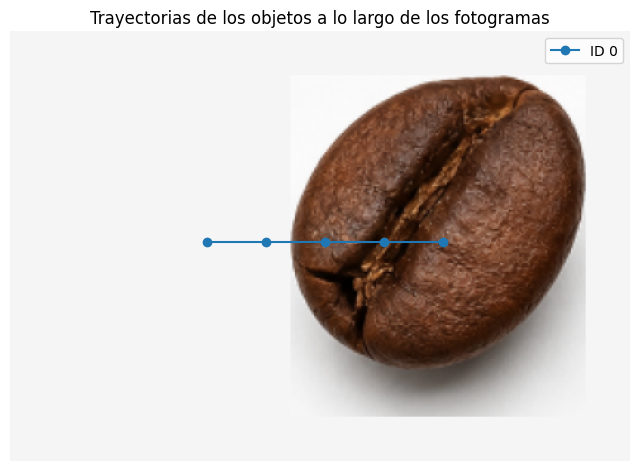

In [20]:
COLORES_TRAYECTORIA = plt.cm.tab10.colors  # paleta con hasta 10 colores distintos, uno por ID

plt.figure(figsize=(8, 6))
plt.imshow(fotogramas_banda[-1])  # usamos el ultimo fotograma como fondo de referencia

for id_objeto, posiciones in trayectorias_objetos.items():
    fotogramas_ordenados = sorted(posiciones.keys())
    puntos_ordenados = [posiciones[numero_fotograma] for numero_fotograma in fotogramas_ordenados]
    coordenadas_x = [punto[0] for punto in puntos_ordenados]
    coordenadas_y = [punto[1] for punto in puntos_ordenados]
    color = COLORES_TRAYECTORIA[id_objeto % len(COLORES_TRAYECTORIA)]
    plt.plot(coordenadas_x, coordenadas_y, "-o", color=color, label=f"ID {id_objeto}")

plt.title("Trayectorias de los objetos a lo largo de los fotogramas")
plt.legend()
plt.axis("off")
plt.show()

## Seccion 21: Nota honesta sobre limitaciones (ej. intercambio de ID si dos objetos quedan cerca) — [BONUS]

**Esta seccion es importante porque...** todo sistema de vision por
computador clasico tiene limitaciones, y reconocerlas explicitamente es parte
de un analisis critico serio, no un defecto del trabajo.

**Aqui se realiza...** una explicacion, con un ejemplo numerico minimo, de la
principal debilidad de nuestro tracker por vecino mas cercano: el intercambio
de identidad (ID swap) cuando dos objetos pasan muy cerca uno del otro.

**Sirve para...** dejar constancia, de cara al reporte final del grupo, de
que este modulo bonus es una simulacion simplificada y de cuales serian los
siguientes pasos (velocidad, apariencia, filtro de Kalman) para hacerlo
robusto en un escenario real con varios objetos.

In [21]:
print("NOTA HONESTA SOBRE LIMITACIONES DEL TRACKER")
print("-" * 60)
print("El emparejamiento por centroide mas cercano (Seccion 19) es muy simple")
print("y funciona bien en nuestra simulacion porque hay un solo objeto que se")
print("mueve de forma suave y predecible. En un caso real con VARIOS objetos:")
print(" 1) Si dos objetos pasan muy cerca uno del otro (a una distancia menor")
print(f"    que DISTANCIA_MAXIMA_EMPAREJAMIENTO={DISTANCIA_MAXIMA_EMPAREJAMIENTO}px),")
print("    el tracker puede intercambiar sus IDs sin darse cuenta (ID swap).")
print(" 2) Si un objeto se pierde durante un fotograma (por ejemplo, por una")
print("    oclusion), se le asigna un ID nuevo en vez de recuperar el anterior.")
print(" 3) No existe un modelo de movimiento (velocidad/direccion): solo se")
print("    compara la posicion actual, por lo que con objetos rapidos o camaras")
print("    a baja tasa de fotogramas por segundo el emparejamiento se degrada.")
print()
print("Demostracion simplificada del problema, con dos objetos que casi se cruzan:")

centroides_t0_demo = [(50, 100), (250, 100)]   # objeto izquierdo y objeto derecho
centroides_t1_demo = [(160, 100), (140, 100)]  # un fotograma despues, casi se cruzaron en el medio

asignaciones_demo = emparejar_centroides_por_cercania(centroides_t0_demo, centroides_t1_demo, distancia_maxima=200)

print(f"Centroides en t0 (orden original): {centroides_t0_demo}")
print(f"Centroides en t1 (orden original): {centroides_t1_demo}")
print(f"Emparejamiento resultante (indice_actual -> indice_previo): {asignaciones_demo}")
print()
print("Con un cruce tan cercano, el objeto que iba por la izquierda puede quedar")
print("emparejado con el que iba por la derecha: ese es exactamente el")
print("intercambio de identidad (ID swap) que un tracker por vecino mas cercano")
print("no puede resolver sin informacion adicional (apariencia visual, un")
print("modelo de velocidad, o un filtro de Kalman, por ejemplo).")

NOTA HONESTA SOBRE LIMITACIONES DEL TRACKER
------------------------------------------------------------
El emparejamiento por centroide mas cercano (Seccion 19) es muy simple
y funciona bien en nuestra simulacion porque hay un solo objeto que se
mueve de forma suave y predecible. En un caso real con VARIOS objetos:
 1) Si dos objetos pasan muy cerca uno del otro (a una distancia menor
    que DISTANCIA_MAXIMA_EMPAREJAMIENTO=100px),
    el tracker puede intercambiar sus IDs sin darse cuenta (ID swap).
 2) Si un objeto se pierde durante un fotograma (por ejemplo, por una
    oclusion), se le asigna un ID nuevo en vez de recuperar el anterior.
 3) No existe un modelo de movimiento (velocidad/direccion): solo se
    compara la posicion actual, por lo que con objetos rapidos o camaras
    a baja tasa de fotogramas por segundo el emparejamiento se degrada.

Demostracion simplificada del problema, con dos objetos que casi se cruzan:
Centroides en t0 (orden original): [(50, 100), (250, 100)]
